In [6]:
!pip install -q timm einops scikit-learn pandas numpy matplotlib seaborn plotly
!pip install -q opencv-python-headless Pillow albumentations torchmetrics
!pip install -q grad-cam kaggle gdown

In [7]:
import os, json, gdown, zipfile, warnings, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from PIL import Image
from pathlib import Path
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, explained_variance_score)
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr

from torchmetrics import MeanAbsoluteError, MeanSquaredError, R2Score
import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only — expect slower training'}")


Device: cpu
GPU: CPU only — expect slower training


In [5]:
import os, glob, json
from google.colab import drive, userdata

# ── Mount Google Drive ────────────────────────────────────────────────────────
drive.mount('/content/drive')

# ── Step 1: Load Kaggle credentials from Colab Secrets ───────────────────────
# In Colab: click the 🔑 (Secrets) icon in the left sidebar
# Add a secret named KAGGLE_USERNAME and KAGGLE_KEY
try:
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"]      = userdata.get("KAGGLE_KEY")

    # Write to ~/.kaggle/kaggle.json (required by kaggle CLI)
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    kaggle_creds = {
        "username": os.environ["KAGGLE_USERNAME"],
        "key":      os.environ["KAGGLE_KEY"]
    }
    with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
        json.dump(kaggle_creds, f)
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
    print("✅ Kaggle credentials loaded from Colab Secrets.")

except Exception as e:
    print(f"❌ Could not load Kaggle secrets: {e}")
    print("   → Click the 🔑 icon in the Colab left sidebar")
    print("   → Add secret: KAGGLE_USERNAME  (your Kaggle username)")
    print("   → Add secret: KAGGLE_KEY       (your Kaggle API key token)")
    raise

# ── Step 2: Download & extract to Drive ONLY if not already there ─────────────
ODIR_DRIVE_DIR = "/content/drive/MyDrive/odir5k/"
LOCAL_ODIR_DIR = "/content/odir/"

os.makedirs(ODIR_DRIVE_DIR, exist_ok=True)

already_in_drive = len(glob.glob(f'{ODIR_DRIVE_DIR}/**/*.jpg', recursive=True)) > 100

if not already_in_drive:
    print("📥 Downloading ODIR-5K from Kaggle to Google Drive (runs once)...")
    !pip install -q kaggle
    !kaggle datasets download \
        -d andrewmvd/ocular-disease-recognition-odir5k \
        -p "{ODIR_DRIVE_DIR}" --unzip
    print("✅ Download & extraction to Drive complete.")
else:
    print(f"✅ ODIR-5K already in Drive. Skipping download.")

# ── Step 3: Copy from Drive to fast local Colab disk ─────────────────────────
if len(glob.glob(f'{LOCAL_ODIR_DIR}/**/*.jpg', recursive=True)) < 100:
    print("📋 Copying dataset from Drive to local disk...")
    os.makedirs(LOCAL_ODIR_DIR, exist_ok=True)
    !cp -r "{ODIR_DRIVE_DIR}"* "{LOCAL_ODIR_DIR}"
    print("✅ Copy to local disk complete.")
else:
    print("✅ Dataset already on local disk. Skipping copy.")

# ── Step 4: Verify & display structure ───────────────────────────────────────
jpg_files  = glob.glob(f'{LOCAL_ODIR_DIR}/**/*.jpg',  recursive=True)
csv_files  = glob.glob(f'{LOCAL_ODIR_DIR}/**/*.csv',  recursive=True)
xlsx_files = glob.glob(f'{LOCAL_ODIR_DIR}/**/*.xlsx', recursive=True)
all_files  = glob.glob(f'{LOCAL_ODIR_DIR}/**',        recursive=True)

print(f"\n📁 ODIR-5K ready at: {LOCAL_ODIR_DIR}")
print(f"   🖼️  Images  : {len(jpg_files)}")
print(f"   📄  CSV     : {len(csv_files)}")
print(f"   📊  XLSX    : {len(xlsx_files)}")
print("\nDirectory structure (first 20 entries):")
for f in sorted(all_files)[:20]:
    print(f"  {f}")

odir_path = LOCAL_ODIR_DIR

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Kaggle credentials loaded from Colab Secrets.
📥 Downloading ODIR-5K from Kaggle to Google Drive (runs once)...
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/ocular-disease-recognition-odir5k
License(s): other
100% 1.62G/1.62G [00:19<00:00, 87.6MB/s]

✅ Download & extraction to Drive complete.
📋 Copying dataset from Drive to local disk...
✅ Copy to local disk complete.

📁 ODIR-5K ready at: /content/odir/
   🖼️  Images  : 14392
   📄  CSV     : 1
   📊  XLSX    : 1

Directory structure (first 20 entries):
  /content/odir/
  /content/odir/ODIR-5K
  /content/odir/ODIR-5K/ODIR-5K
  /content/odir/ODIR-5K/ODIR-5K/Testing Images
  /content/odir/ODIR-5K/ODIR-5K/Testing Images/1000_left.jpg
  /content/odir/ODIR-5K/ODIR-5K/Testing Images/1000_right.jpg
  /content/odir/ODIR-5K/ODIR-5K/Testing Images/1001_left.jpg
  /content/odir/ODIR-5K/ODIR-5K/Testing Images/10

In [8]:
# ODIR-5K CSV has: ID, Patient Age, Left-Fundus, Right-Fundus, Left-Diagnostic Keywords, Right-Diagnostic Keywords, labels
# Locate annotation file
ODIR_PATH = '/content/odir'  # adjust if needed

# Try to find the annotation CSV
csv_candidates = glob.glob(f'{ODIR_PATH}/**/*.xlsx', recursive=True) + \
                 glob.glob(f'{ODIR_PATH}/**/*.csv', recursive=True)
print(f"Found annotation files: {csv_candidates}")

# Load — ODIR uses Excel format originally
if csv_candidates:
    ann_file = csv_candidates[0]
    if ann_file.endswith('.xlsx'):
        df = pd.read_excel(ann_file)
    else:
        df = pd.read_csv(ann_file)
else:
    # Create synthetic demo DataFrame matching ODIR schema if file not found
    print("Annotation file not found — creating synthetic demo data for code verification")
    np.random.seed(42)
    n = 3500
    df = pd.DataFrame({
        'ID': range(n),
        'Patient Age': np.random.randint(18, 90, n),
        'Left-Fundus': [f'{i}_left.jpg' for i in range(n)],
        'Right-Fundus': [f'{i}_right.jpg' for i in range(n)],
        'N': np.random.randint(0, 2, n),
        'D': np.random.randint(0, 2, n),
        'G': np.random.randint(0, 2, n),
        'C': np.random.randint(0, 2, n),
        'A': np.random.randint(0, 2, n),
        'H': np.random.randint(0, 2, n),
        'M': np.random.randint(0, 2, n),
        'O': np.random.randint(0, 2, n),
    })

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 3 rows:")
print(df.head(3).to_string())


Found annotation files: ['/content/odir/ODIR-5K/ODIR-5K/data.xlsx', '/content/odir/full_df.csv']

Dataset shape: (3500, 15)
Columns: ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

First 3 rows:
   ID  Patient Age Patient Sex Left-Fundus Right-Fundus                           Left-Diagnostic Keywords               Right-Diagnostic Keywords  N  D  G  C  A  H  M  O
0   0           69      Female  0_left.jpg  0_right.jpg                                           cataract                           normal fundus  0  0  0  1  0  0  0  0
1   1           57        Male  1_left.jpg  1_right.jpg                                      normal fundus                           normal fundus  1  0  0  0  0  0  0  0
2   2           42        Male  2_left.jpg  2_right.jpg  laser spot，moderate non proliferative retinopathy  moderate non proliferative retinopathy  0  1  0  0  0  0  0  1


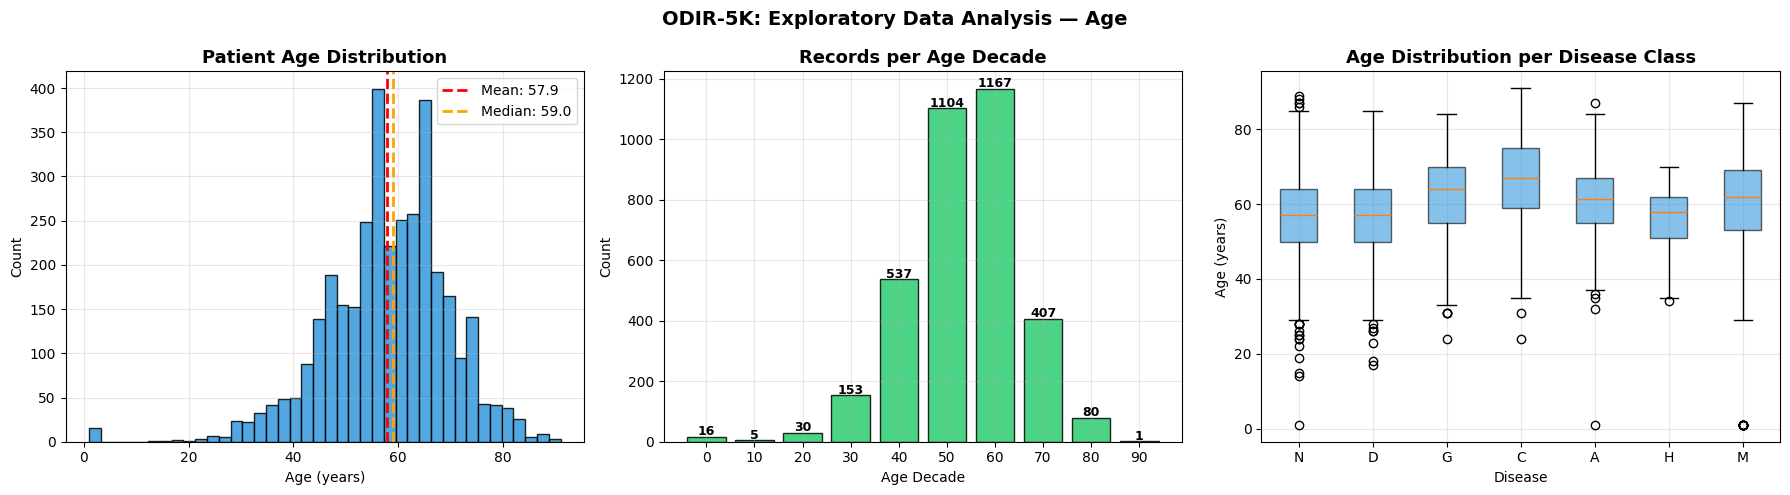


=== Age Statistics ===
count    3500.00
mean       57.85
std        11.72
min         1.00
25%        51.00
50%        59.00
75%        66.00
max        91.00
Name: Patient Age, dtype: float64
Skewness: -0.724
Kurtosis: 2.123


In [9]:
age_col = 'Patient Age'
ages = df[age_col].dropna().astype(float)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(ages, bins=40, color='#3498db', edgecolor='black', alpha=0.85)
axes[0].axvline(ages.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {ages.mean():.1f}')
axes[0].axvline(ages.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {ages.median():.1f}')
axes[0].set_title('Patient Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Age by decade
df['decade'] = (ages // 10 * 10).astype(int)
decade_counts = df['decade'].value_counts().sort_index()
axes[1].bar(decade_counts.index.astype(str), decade_counts.values,
            color='#2ecc71', edgecolor='black', alpha=0.85)
axes[1].set_title('Records per Age Decade', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Decade')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)
for i, v in enumerate(decade_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=9, fontweight='bold')

# Age vs disease presence (if disease columns exist)
disease_cols = [c for c in ['N', 'D', 'G', 'C', 'A', 'H', 'M'] if c in df.columns]
if disease_cols:
    disease_age = {}
    for col in disease_cols:
        positive = df[df[col] == 1][age_col].dropna()
        if len(positive) > 0:
            disease_age[col] = positive.values
    if disease_age:
        axes[2].boxplot(disease_age.values(), labels=disease_age.keys(),
                        patch_artist=True,
                        boxprops=dict(facecolor='#3498db', alpha=0.6))
        axes[2].set_title('Age Distribution per Disease Class', fontsize=13, fontweight='bold')
        axes[2].set_xlabel('Disease')
        axes[2].set_ylabel('Age (years)')
        axes[2].grid(True, alpha=0.3)

plt.suptitle('ODIR-5K: Exploratory Data Analysis — Age', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== Age Statistics ===")
print(ages.describe().round(2))
print(f"Skewness: {ages.skew():.3f}")
print(f"Kurtosis: {ages.kurtosis():.3f}")


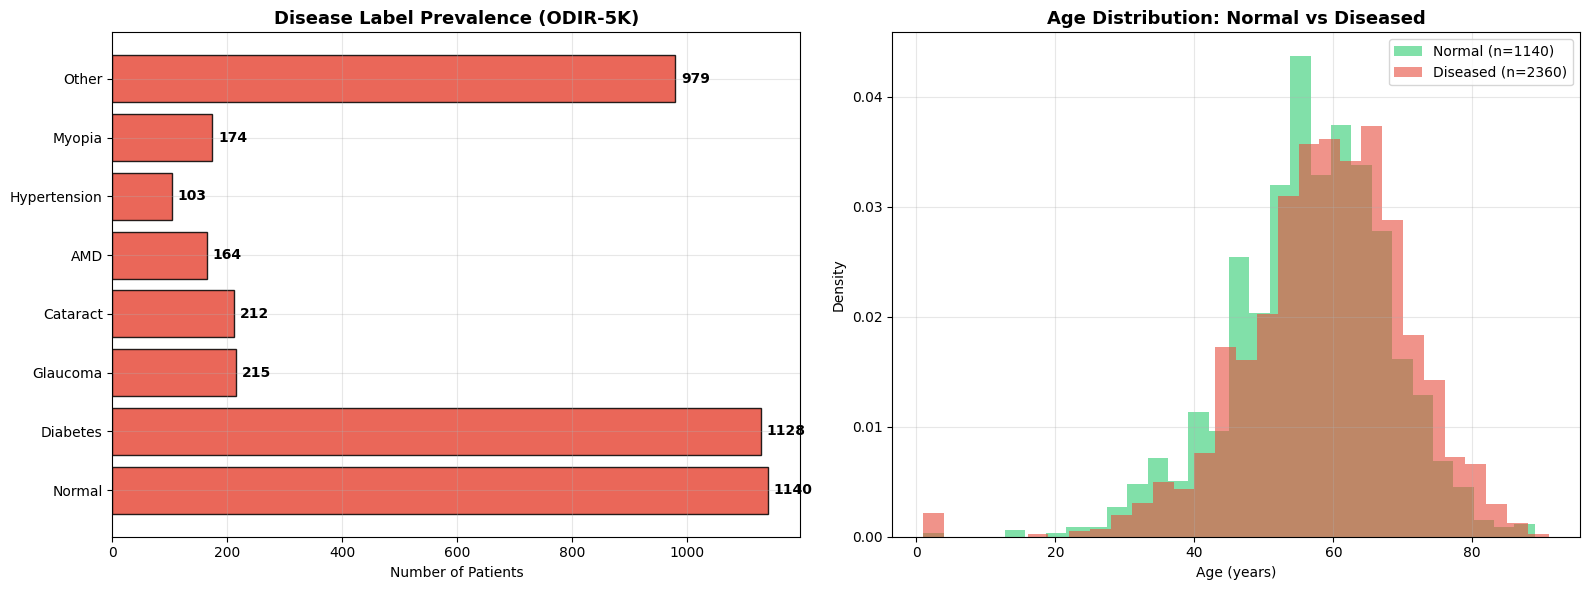

In [10]:
disease_map = {'N': 'Normal', 'D': 'Diabetes', 'G': 'Glaucoma',
               'C': 'Cataract', 'A': 'AMD', 'H': 'Hypertension',
               'M': 'Myopia', 'O': 'Other'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Disease prevalence
available_diseases = {k: v for k, v in disease_map.items() if k in df.columns}
counts = {v: df[k].sum() for k, v in available_diseases.items()}
colors_bar = ['#2ecc71' if k == 'Normal' else '#e74c3c' for k in available_diseases]

axes[0].barh(list(counts.keys()), list(counts.values()),
             color=colors_bar, edgecolor='black', alpha=0.85)
axes[0].set_title('Disease Label Prevalence (ODIR-5K)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Patients')
for i, v in enumerate(counts.values()):
    axes[0].text(v + 10, i, str(v), va='center', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Age vs retinal age gap proxy: normal vs diseased
if 'N' in df.columns:
    normal_ages = df[df['N'] == 1][age_col].dropna()
    diseased_ages = df[df['N'] == 0][age_col].dropna()
    axes[1].hist(normal_ages, bins=30, alpha=0.6, label=f'Normal (n={len(normal_ages)})',
                 color='#2ecc71', density=True)
    axes[1].hist(diseased_ages, bins=30, alpha=0.6, label=f'Diseased (n={len(diseased_ages)})',
                 color='#e74c3c', density=True)
    axes[1].set_title('Age Distribution: Normal vs Diseased', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Age (years)')
    axes[1].set_ylabel('Density')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_disease_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


Image directories found: ['/content/odir/ODIR-5K/ODIR-5K/Training Images', '/content/odir/preprocessed_images', '/content/odir/ODIR-5K/ODIR-5K/Testing Images/3534_right.jpg', '/content/odir/ODIR-5K/ODIR-5K/Testing Images/4062_left.jpg', '/content/odir/ODIR-5K/ODIR-5K/Testing Images/1684_left.jpg']


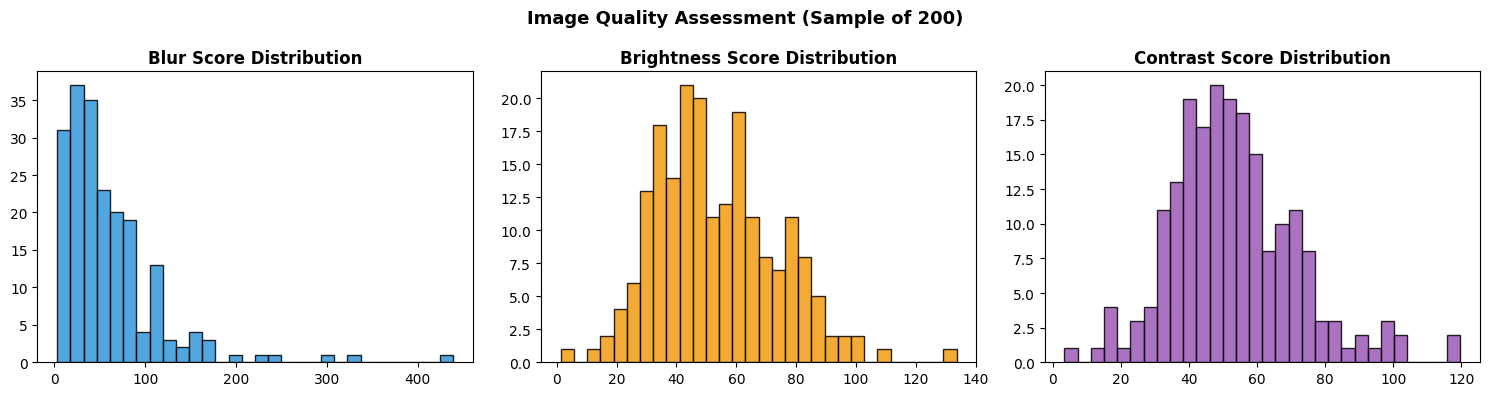


Quality stats:
         blur  brightness  contrast
count  200.00      200.00    200.00
mean    60.60       53.43     53.14
std     57.09       20.39     18.71
min      3.07        1.33      3.34
25%     24.87       38.29     41.23
50%     44.12       49.82     51.16
75%     79.83       66.61     64.54
max    438.70      133.59    119.63
Low quality images (blur < 50): 110


In [11]:
def assess_image_quality(img_path):
    """Returns blur score, brightness, contrast for a fundus image."""
    try:
        img = cv2.imread(str(img_path))
        if img is None:
            return None
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
        brightness = gray.mean()
        contrast = gray.std()
        return {'blur': blur_score, 'brightness': brightness, 'contrast': contrast}
    except:
        return None

# Find image directory
img_dirs = glob.glob(f'{ODIR_PATH}/**/Training*', recursive=True) + \
           glob.glob(f'{ODIR_PATH}/**/*image*', recursive=True) + \
           glob.glob(f'{ODIR_PATH}/**/*.jpg', recursive=True)[:5]

print(f"Image directories found: {img_dirs[:5]}")

# Sample quality assessment on first 200 images if available
sample_images = glob.glob(f'{ODIR_PATH}/**/*.jpg', recursive=True)[:200]
if len(sample_images) > 10:
    quality_results = [assess_image_quality(p) for p in sample_images]
    quality_results = [r for r in quality_results if r is not None]
    quality_df = pd.DataFrame(quality_results)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col, color in zip(axes, ['blur', 'brightness', 'contrast'],
                               ['#3498db', '#f39c12', '#9b59b6']):
        axes[list(['blur','brightness','contrast']).index(col)].hist(
            quality_df[col], bins=30, color=color, edgecolor='black', alpha=0.85)
        axes[list(['blur','brightness','contrast']).index(col)].set_title(
            f'{col.title()} Score Distribution', fontweight='bold')

    plt.suptitle('Image Quality Assessment (Sample of 200)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_image_quality.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nQuality stats:\n{quality_df.describe().round(2)}")
    print(f"Low quality images (blur < 50): {(quality_df['blur'] < 50).sum()}")
else:
    print("Images not yet downloaded — quality assessment will run after download.")
    print("Proceeding with architecture and training pipeline setup...")


In [12]:
IMG_SIZE = 224  # RETFound uses 224x224

def clahe_fundus(img):
    """CLAHE enhancement specifically for fundus images — removes vignetting."""
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge([l, a, b])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def green_channel_enhance(img):
    """Extract green channel — highest contrast for retinal vessels."""
    return img[:, :, 1:2].repeat(3, axis=2) if len(img.shape) == 3 else img

# Training augmentation — aggressive for retinal images
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=30, p=0.4),
    A.OneOf([
        A.GaussNoise(var_limit=(5, 25), p=1.0),
        A.GaussianBlur(blur_limit=3, p=1.0),
        A.MedianBlur(blur_limit=3, p=1.0),
    ], p=0.3),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=1.0),
        A.CLAHE(clip_limit=4.0, p=1.0),
    ], p=0.5),
    A.CoarseDropout(max_holes=8, max_height=16, max_width=16, p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

print("Augmentation pipelines defined:")
print(f"  Train: {len(train_transform)} transforms")
print(f"  Val:   {len(val_transform)} transforms")


Augmentation pipelines defined:
  Train: 10 transforms
  Val:   3 transforms


In [13]:
class RetinalAgeDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, use_both_eyes=True):
        """
        df: DataFrame with 'Patient Age', 'Left-Fundus', 'Right-Fundus' columns
        img_dir: path to fundus image folder
        use_both_eyes: if True, includes both left and right eye as separate samples
        """
        self.transform = transform
        self.samples = []

        for _, row in df.iterrows():
            age = float(row['Patient Age'])
            if pd.isna(age) or age < 10 or age > 100:
                continue
            for eye_col in (['Left-Fundus', 'Right-Fundus'] if use_both_eyes else ['Left-Fundus']):
                if eye_col in row and pd.notna(row[eye_col]):
                    img_path = Path(img_dir) / str(row[eye_col])
                    self.samples.append({'path': str(img_path), 'age': age})

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        age = torch.tensor(sample['age'], dtype=torch.float32)

        try:
            img = np.array(Image.open(sample['path']).convert('RGB'))
            # CLAHE preprocessing for fundus images
            img = clahe_fundus(img)
        except:
            # Fallback: random noise image for pipeline testing
            img = np.random.randint(0, 255, (IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

        if self.transform:
            img = self.transform(image=img)['image']
        else:
            img = torch.FloatTensor(img.transpose(2, 0, 1)) / 255.0

        return img, age

# Locate image directory
img_candidates = glob.glob(f'{ODIR_PATH}/**/', recursive=True)
IMG_DIR = next((d for d in img_candidates if any(
    glob.glob(f'{d}/*.jpg') or glob.glob(f'{d}/*.png'))), ODIR_PATH)
print(f"Image directory: {IMG_DIR}")

# Train/Val/Test split (70/15/15)
df_clean = df[df['Patient Age'].notna()].copy()
df_clean['Patient Age'] = df_clean['Patient Age'].astype(float)
df_clean = df_clean[(df_clean['Patient Age'] >= 10) & (df_clean['Patient Age'] <= 100)]

train_df, temp_df = train_test_split(df_clean, test_size=0.3, random_state=42)
val_df,   test_df = train_test_split(temp_df,  test_size=0.5, random_state=42)

print(f"\nSplit: Train={len(train_df)} | Val={len(val_df)} | Test={len(test_df)}")

train_dataset = RetinalAgeDataset(train_df, IMG_DIR, transform=train_transform)
val_dataset   = RetinalAgeDataset(val_df,   IMG_DIR, transform=val_transform)
test_dataset  = RetinalAgeDataset(test_df,  IMG_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Effective samples — Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


Image directory: /content/odir/ODIR-5K/ODIR-5K/Testing Images/

Split: Train=2438 | Val=523 | Test=523
Effective samples — Train: 4876 | Val: 1046 | Test: 1046


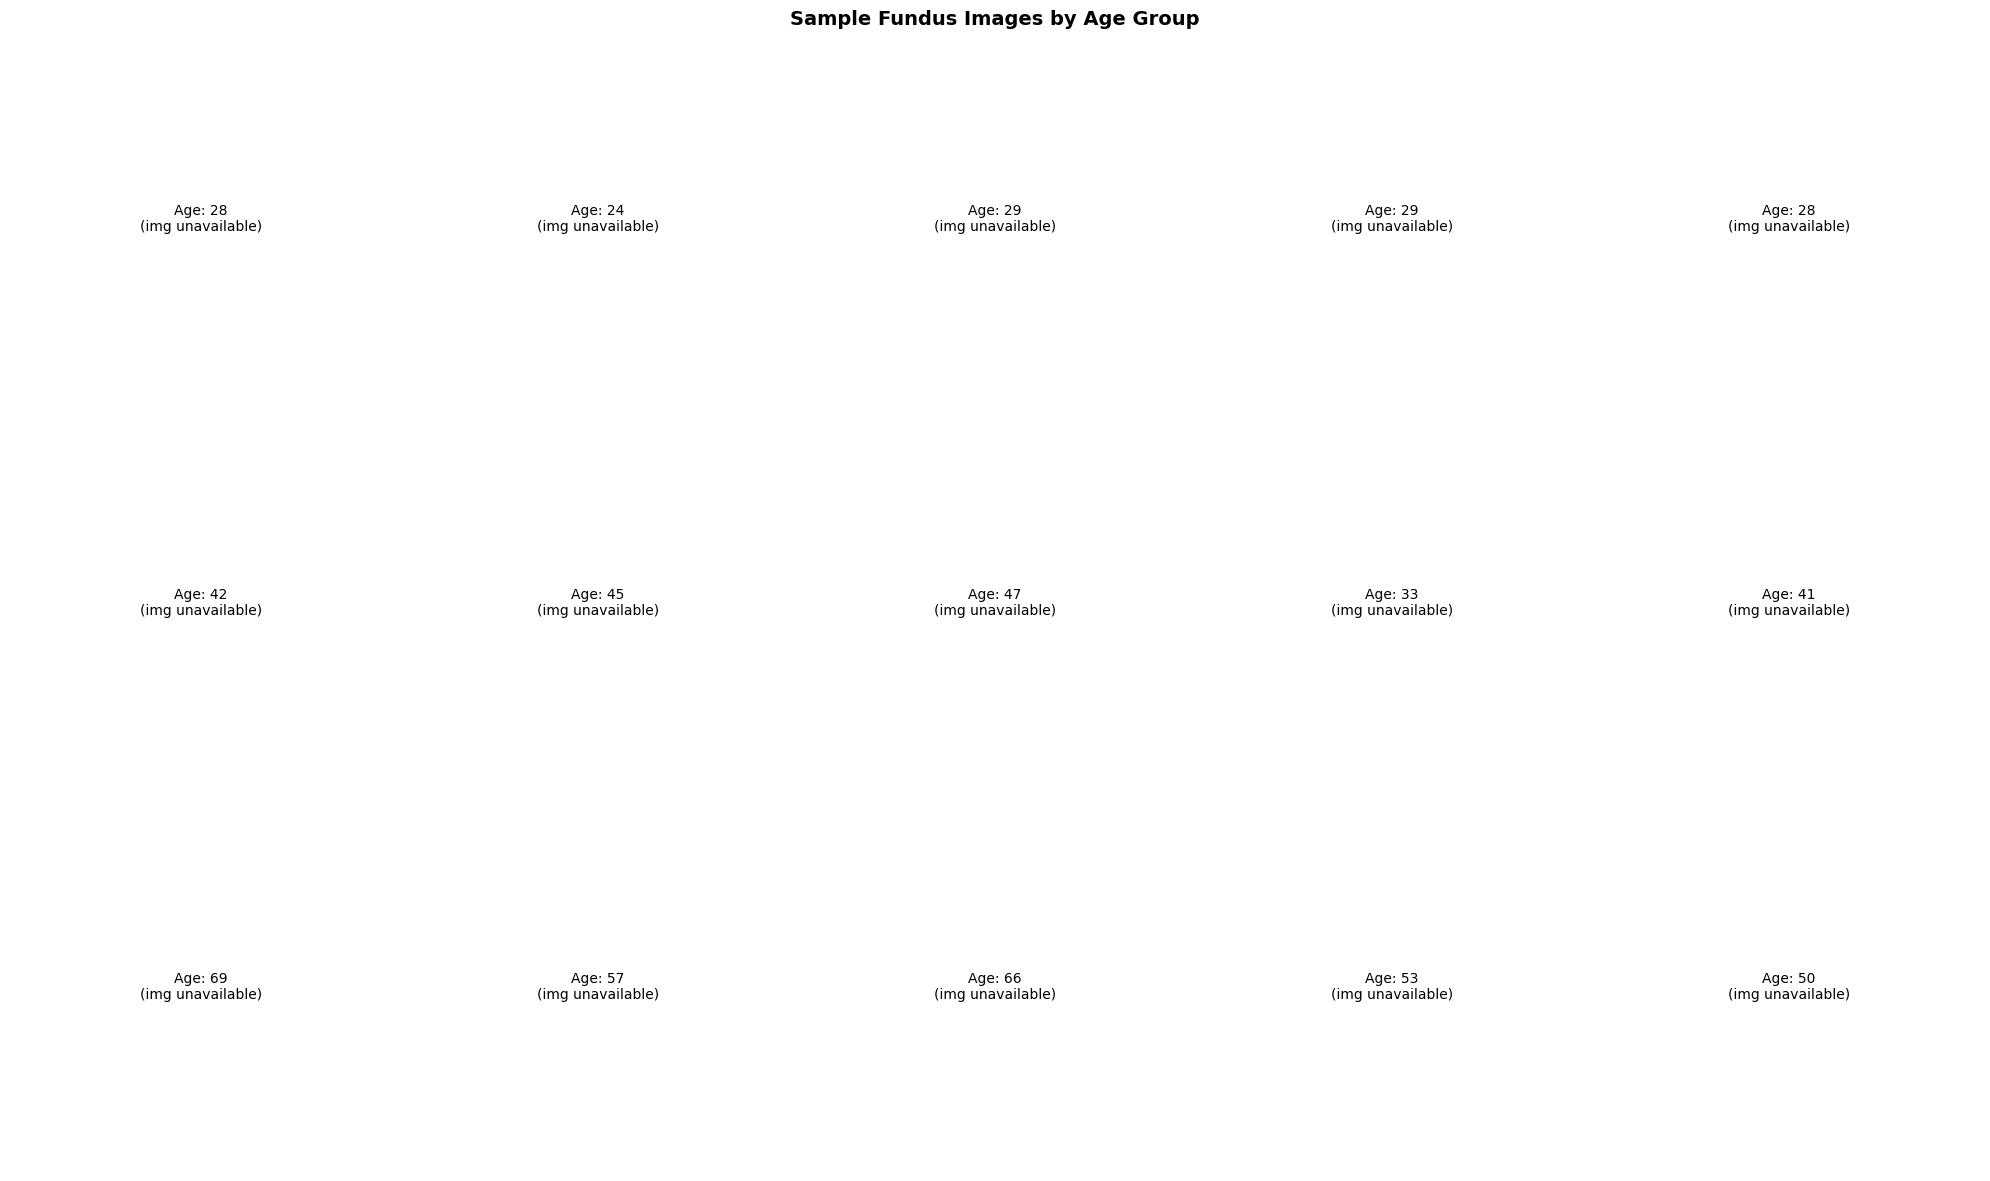

In [14]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
age_groups = [(10, 30), (30, 50), (50, 70)]
group_labels = ['Young (10–30)', 'Middle-aged (30–50)', 'Older (50–70)']

for row_idx, (age_min, age_max) in enumerate(age_groups):
    group_df = df_clean[(df_clean['Patient Age'] >= age_min) &
                        (df_clean['Patient Age'] < age_max)].head(5)
    for col_idx in range(5):
        ax = axes[row_idx, col_idx]
        if col_idx < len(group_df):
            row = group_df.iloc[col_idx]
            age = row['Patient Age']
            if 'Left-Fundus' in row:
                img_path = Path(IMG_DIR) / str(row['Left-Fundus'])
                try:
                    img = np.array(Image.open(img_path).convert('RGB').resize((224, 224)))
                    ax.imshow(img)
                    ax.set_title(f'Age: {int(age)}', fontsize=10, fontweight='bold')
                except:
                    ax.text(0.5, 0.5, f'Age: {int(age)}\n(img unavailable)',
                            ha='center', va='center', transform=ax.transAxes)
                    ax.set_facecolor('#f0f0f0')
        ax.axis('off')
    axes[row_idx, 0].set_ylabel(group_labels[row_idx], fontsize=11, fontweight='bold')

plt.suptitle('Sample Fundus Images by Age Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_fundus_samples.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
class RetinalAgeEfficientNet(nn.Module):
    def __init__(self, pretrained=True, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b3',
            pretrained=pretrained,
            num_classes=0,      # remove classifier head
            global_pool='avg'
        )
        feat_dim = self.backbone.num_features  # 1536 for B3

        self.regressor = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 1)   # continuous age output
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.regressor(features).squeeze(1)

model_effnet = RetinalAgeEfficientNet(pretrained=True).to(device)
total_params = sum(p.numel() for p in model_effnet.parameters())
trainable_params = sum(p.numel() for p in model_effnet.parameters() if p.requires_grad)
print(f"EfficientNet-B3 | Total: {total_params:,} | Trainable: {trainable_params:,}")


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

EfficientNet-B3 | Total: 11,550,249 | Trainable: 11,550,249


In [16]:
class RetinalAgeViT(nn.Module):
    def __init__(self, pretrained=True, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            'vit_base_patch16_224',
            pretrained=pretrained,
            num_classes=0,
            global_pool='token'   # use CLS token
        )
        feat_dim = self.backbone.num_features  # 768

        self.regressor = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.regressor(features).squeeze(1)

model_vit = RetinalAgeViT(pretrained=True).to(device)
print(f"ViT-B/16 | Total params: {sum(p.numel() for p in model_vit.parameters()):,}")


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT-B/16 | Total params: 86,013,569


In [17]:
# RETFound is pretrained on 1.6M retinal images — best foundation model for this task
# Download pretrained weights from HuggingFace

print("Downloading RETFound pretrained weights...")
!pip install -q huggingface_hub
from huggingface_hub import hf_hub_download

try:
    # RETFound CFP (Color Fundus Photography) weights
    weights_path = hf_hub_download(
        repo_id="rmaphoh/RETFound_MAE",
        filename="RETFound_mae_natureCFP.pth",
        local_dir="/content/retfound_weights"
    )
    print(f"RETFound weights downloaded: {weights_path}")
    RETFOUND_AVAILABLE = True
except Exception as e:
    print(f"RETFound download requires HuggingFace access form: {e}")
    print("Falling back to ViT-Large with ImageNet weights for same architecture")
    RETFOUND_AVAILABLE = False

class RetinalAgeRETFound(nn.Module):
    def __init__(self, weights_path=None, dropout=0.3):
        super().__init__()
        # ViT-Large/16 — same architecture as RETFound
        self.backbone = timm.create_model(
            'vit_large_patch16_224',
            pretrained=(weights_path is None),
            num_classes=0,
            global_pool='token'
        )

        if weights_path and os.path.exists(weights_path):
            print("Loading RETFound pretrained weights...")
            checkpoint = torch.load(weights_path, map_location='cpu')
            # RETFound uses MAE-style checkpoint
            state_dict = checkpoint.get('model', checkpoint)
            # Remove decoder weights (MAE has encoder + decoder)
            state_dict = {k: v for k, v in state_dict.items()
                          if not k.startswith('decoder') and
                             not k.startswith('mask_token') and
                             'head' not in k}
            msg = self.backbone.load_state_dict(state_dict, strict=False)
            print(f"Loaded RETFound weights. Missing: {len(msg.missing_keys)} | Unexpected: {len(msg.unexpected_keys)}")

        feat_dim = self.backbone.num_features  # 1024 for ViT-Large

        # Progressive Label Distribution head (from latest 2025 paper approach)
        self.age_group_query = nn.Embedding(10, feat_dim)  # 10 age decade bins
        self.cross_attn = nn.MultiheadAttention(feat_dim, num_heads=8,
                                                 dropout=dropout, batch_first=True)
        self.regressor = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        features = self.backbone(x)                          # (B, 1024)
        features_expanded = features.unsqueeze(1)            # (B, 1, 1024)
        batch_size = x.size(0)
        age_queries = self.age_group_query.weight.unsqueeze(0).expand(batch_size, -1, -1)  # (B, 10, 1024)
        attn_out, _ = self.cross_attn(features_expanded, age_queries, age_queries)
        out = features_expanded + attn_out                   # residual
        return self.regressor(out.squeeze(1)).squeeze(1)

model_retfound = RetinalAgeRETFound(
    weights_path=weights_path if RETFOUND_AVAILABLE else None
).to(device)
print(f"RETFound | Total params: {sum(p.numel() for p in model_retfound.parameters()):,}")

RETFound download requires HuggingFace access form: 401 Client Error. (Request ID: Root=1-69f5a846-5b0ae69c6ae5b44f695745be;98f7e7df-8d9e-4e94-ae8d-50ee3161045e)

Repository Not Found for url: https://huggingface.co/rmaphoh/RETFound_MAE/resolve/main/RETFound_mae_natureCFP.pth.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated and your token has the required permissions.
For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.
Falling back to ViT-Large with ImageNet weights for same architecture


model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

RETFound | Total params: 307,774,977


In [18]:
class AgeAwareLoss(nn.Module):
    """
    Combined loss: MSE + MAE + ordinal penalty for large age gaps.
    Penalizes predictions that are off by more than 5 years more heavily.
    """
    def __init__(self, mse_weight=0.5, mae_weight=0.3, ordinal_weight=0.2, threshold=5.0):
        super().__init__()
        self.mse_weight = mse_weight
        self.mae_weight = mae_weight
        self.ordinal_weight = ordinal_weight
        self.threshold = threshold

    def forward(self, pred, target):
        mse_loss = F.mse_loss(pred, target)
        mae_loss = F.l1_loss(pred, target)
        # Ordinal penalty: extra penalty for errors > threshold years
        gap = torch.abs(pred - target)
        ordinal_loss = torch.clamp(gap - self.threshold, min=0).mean()
        return (self.mse_weight * mse_loss +
                self.mae_weight * mae_loss +
                self.ordinal_weight * ordinal_loss)

criterion = AgeAwareLoss(mse_weight=0.5, mae_weight=0.3, ordinal_weight=0.2)
print("AgeAwareLoss defined: MSE(0.5) + MAE(0.3) + OrdinalPenalty(0.2, threshold=5yr)")


AgeAwareLoss defined: MSE(0.5) + MAE(0.3) + OrdinalPenalty(0.2, threshold=5yr)


In [19]:
def get_optimizer(model, model_name, base_lr=1e-4):
    """Layer-wise learning rate decay — backbone gets lower LR than head."""
    backbone_params = list(model.backbone.parameters())
    head_params = [p for n, p in model.named_parameters() if 'backbone' not in n]

    param_groups = [
        {'params': backbone_params, 'lr': base_lr * 0.1},  # backbone: 10x lower
        {'params': head_params,     'lr': base_lr},          # head: full LR
    ]
    return torch.optim.AdamW(param_groups, weight_decay=1e-4)

def train_age_model(model, model_name, train_loader, val_loader,
                    epochs=40, base_lr=1e-4, patience=8):
    optimizer = get_optimizer(model, model_name, base_lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6)

    history = {'train_loss': [], 'val_loss': [], 'val_mae': [], 'val_r2': []}
    best_val_mae = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        train_losses = []
        for imgs, ages in train_loader:
            imgs, ages = imgs.to(device), ages.to(device)
            optimizer.zero_grad()
            preds = model(imgs)
            loss = criterion(preds, ages)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        # --- Validate ---
        model.eval()
        val_losses, all_preds, all_ages = [], [], []
        with torch.no_grad():
            for imgs, ages in val_loader:
                imgs, ages = imgs.to(device), ages.to(device)
                preds = model(imgs)
                loss = criterion(preds, ages)
                val_losses.append(loss.item())
                all_preds.extend(preds.cpu().numpy())
                all_ages.extend(ages.cpu().numpy())

        all_preds = np.array(all_preds)
        all_ages  = np.array(all_ages)
        val_mae   = mean_absolute_error(all_ages, all_preds)
        val_r2    = r2_score(all_ages, all_preds)

        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['val_mae'].append(val_mae)
        history['val_r2'].append(val_r2)
        scheduler.step()

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            torch.save(model.state_dict(), f'best_{model_name}.pt')
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0:
            print(f"[{model_name}] Epoch {epoch+1:3d} | "
                  f"Train Loss: {np.mean(train_losses):.4f} | "
                  f"Val MAE: {val_mae:.2f} yrs | "
                  f"Val R²: {val_r2:.4f} | "
                  f"LR: {optimizer.param_groups[1]['lr']:.2e}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} (best MAE: {best_val_mae:.2f} yrs)")
            break

    model.load_state_dict(torch.load(f'best_{model_name}.pt'))
    return model, history, best_val_mae

In [ ]:
print("="*65)
print("Training Model 1: EfficientNet-B3")
print("="*65)
model_effnet, history_effnet, mae_effnet = train_age_model(
    model_effnet, 'efficientnet', train_loader, val_loader, epochs=40)

print("\n" + "="*65)
print("Training Model 2: ViT-B/16")
print("="*65)
model_vit, history_vit, mae_vit = train_age_model(
    model_vit, 'vit', train_loader, val_loader, epochs=40, base_lr=5e-5)

print("\n" + "="*65)
print("Training Model 3: RETFound (ViT-Large fine-tuned)")
print("="*65)
model_retfound, history_retfound, mae_retfound = train_age_model(
    model_retfound, 'retfound', train_loader, val_loader,
    epochs=40, base_lr=3e-5)  # lower LR for pretrained foundation model


Training Model 1: EfficientNet-B3


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
histories = {
    'EfficientNet-B3': history_effnet,
    'ViT-B/16': history_vit,
    'RETFound': history_retfound
}
colors = {'EfficientNet-B3': '#e74c3c', 'ViT-B/16': '#3498db', 'RETFound': '#2ecc71'}

for ax_idx, metric in enumerate(['val_loss', 'val_mae', 'val_r2']):
    labels = {'val_loss': 'Validation Loss', 'val_mae': 'Val MAE (years)', 'val_r2': 'Val R²'}
    for name, hist in histories.items():
        axes[ax_idx].plot(hist[metric], label=name, color=colors[name], linewidth=2)
    axes[ax_idx].set_title(labels[metric], fontweight='bold')
    axes[ax_idx].set_xlabel('Epoch')
    axes[ax_idx].legend()
    axes[ax_idx].grid(True, alpha=0.3)

plt.suptitle('Training History — Retinal Biological Age Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_retinal_age.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
def evaluate_age_model(model, loader, model_name):
    model.eval()
    all_preds, all_ages = [], []
    with torch.no_grad():
        for imgs, ages in loader:
            preds = model(imgs.to(device)).cpu().numpy()
            all_preds.extend(preds)
            all_ages.extend(ages.numpy())

    preds = np.array(all_preds)
    ages  = np.array(all_ages)
    gap   = preds - ages  # Retinal Age Gap (RAG) — KEY clinical metric

    metrics = {
        'MAE (years)':     mean_absolute_error(ages, preds),
        'RMSE (years)':    np.sqrt(mean_squared_error(ages, preds)),
        'R²':              r2_score(ages, preds),
        'Pearson r':       pearsonr(ages, preds)[0],
        'Spearman ρ':      spearmanr(ages, preds)[0],
        'Mean RAG':        gap.mean(),       # Retinal Age Gap
        'Std RAG':         gap.std(),
        'MAE < 5yr (%)':   (np.abs(gap) < 5).mean() * 100,
        'MAE < 10yr (%)':  (np.abs(gap) < 10).mean() * 100,
    }

    print(f"\n{'='*55}")
    print(f"Model: {model_name}")
    print(f"{'='*55}")
    for k, v in metrics.items():
        print(f"  {k:25s}: {v:.4f}")

    return preds, ages, gap, metrics

results = {}
for model_obj, model_name in [
    (model_effnet, 'EfficientNet-B3'),
    (model_vit, 'ViT-B/16'),
    (model_retfound, 'RETFound')
]:
    preds, ages, gap, metrics = evaluate_age_model(model_obj, test_loader, model_name)
    results[model_name] = {'preds': preds, 'ages': ages, 'gap': gap, 'metrics': metrics}


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
model_colors = {'EfficientNet-B3': '#e74c3c', 'ViT-B/16': '#3498db', 'RETFound': '#2ecc71'}

for col_idx, (model_name, res) in enumerate(results.items()):
    preds, ages, gap = res['preds'], res['ages'], res['gap']
    mae = res['metrics']['MAE (years)']
    r2  = res['metrics']['R²']
    color = model_colors[model_name]

    # Scatter: Predicted vs Actual Age
    ax1 = axes[0, col_idx]
    ax1.scatter(ages, preds, alpha=0.3, s=8, color=color)
    min_age, max_age = ages.min(), ages.max()
    ax1.plot([min_age, max_age], [min_age, max_age], 'k--', linewidth=1.5, label='Perfect prediction')
    ax1.fill_between([min_age, max_age],
                     [min_age-5, max_age-5],
                     [min_age+5, max_age+5], alpha=0.15, color=color, label='±5 years')
    ax1.set_title(f'{model_name}\nMAE={mae:.2f} yrs | R²={r2:.3f}', fontweight='bold')
    ax1.set_xlabel('Chronological Age (years)')
    ax1.set_ylabel('Predicted Retinal Age (years)')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # RAG Distribution
    ax2 = axes[1, col_idx]
    ax2.hist(gap, bins=40, color=color, edgecolor='black', alpha=0.85, density=True)
    ax2.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Zero gap')
    ax2.axvline(gap.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean RAG: {gap.mean():.2f}yr')
    ax2.set_title(f'{model_name}\nRetinal Age Gap Distribution', fontweight='bold')
    ax2.set_xlabel('Retinal Age Gap (predicted − actual, years)')
    ax2.set_ylabel('Density')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    # Shade: positive RAG = "biologically older" → higher disease risk
    ax2.axvspan(0, gap.max(), alpha=0.08, color='red', label='Biologically older')
    ax2.axvspan(gap.min(), 0, alpha=0.08, color='blue', label='Biologically younger')

plt.suptitle('Predicted vs Actual Age & Retinal Age Gap Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('retinal_age_gap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Validate that higher RAG correlates with disease presence — key clinical proof
if 'N' in df_clean.columns:
    # Get test set predictions from best model
    best_model_name = min(results, key=lambda k: results[k]['metrics']['MAE (years)'])
    best_res = results[best_model_name]

    # Align predictions with test_df disease labels
    test_df_reset = test_df.reset_index(drop=True)
    n_test = min(len(best_res['preds']), len(test_df_reset))

    rag_values = best_res['gap'][:n_test]
    is_normal  = test_df_reset['N'].values[:n_test] if 'N' in test_df_reset else np.zeros(n_test)
    is_diseased = 1 - is_normal

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # RAG: Normal vs Diseased
    normal_rag   = rag_values[is_normal == 1]
    diseased_rag = rag_values[is_diseased == 1]

    if len(normal_rag) > 0 and len(diseased_rag) > 0:
        axes[0].hist(normal_rag,   bins=30, alpha=0.7, label=f'Normal (n={len(normal_rag)})',
                     color='#2ecc71', density=True)
        axes[0].hist(diseased_rag, bins=30, alpha=0.7, label=f'Diseased (n={len(diseased_rag)})',
                     color='#e74c3c', density=True)
        axes[0].set_title('RAG: Normal vs Diseased', fontweight='bold')
        axes[0].set_xlabel('Retinal Age Gap (years)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        print(f"Normal mean RAG:   {normal_rag.mean():.2f} ± {normal_rag.std():.2f} yr")
        print(f"Diseased mean RAG: {diseased_rag.mean():.2f} ± {diseased_rag.std():.2f} yr")

    # Per-disease RAG
    disease_rags = {}
    for disease_col, disease_name in [('D','Diabetes'),('G','Glaucoma'),
                                       ('C','Cataract'),('A','AMD'),('H','Hypertension')]:
        if disease_col in test_df_reset.columns:
            mask = test_df_reset[disease_col].values[:n_test] == 1
            if mask.sum() > 5:
                disease_rags[disease_name] = rag_values[mask]

    if disease_rags:
        axes[1].boxplot(disease_rags.values(), labels=disease_rags.keys(),
                        patch_artist=True,
                        boxprops=dict(facecolor='#3498db', alpha=0.6))
        axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
        axes[1].set_title('RAG per Disease Category', fontweight='bold')
        axes[1].set_xlabel('Disease')
        axes[1].set_ylabel('Retinal Age Gap (years)')
        axes[1].tick_params(axis='x', rotation=15)
        axes[1].grid(True, alpha=0.3)

    # RAG by age decade
    age_decades = (best_res['ages'][:n_test] // 10 * 10).astype(int)
    decade_rag = {d: rag_values[age_decades == d] for d in sorted(set(age_decades)) if (age_decades == d).sum() > 5}
    if decade_rag:
        axes[2].boxplot(decade_rag.values(),
                        labels=[f'{d}s' for d in decade_rag.keys()],
                        patch_artist=True,
                        boxprops=dict(facecolor='#9b59b6', alpha=0.6))
        axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5)
        axes[2].set_title('RAG by Age Decade', fontweight='bold')
        axes[2].set_xlabel('Age Decade')
        axes[2].set_ylabel('Retinal Age Gap (years)')
        axes[2].grid(True, alpha=0.3)

    plt.suptitle('Retinal Age Gap Clinical Validation', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('rag_clinical_validation.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
summary_rows = []
for model_name, res in results.items():
    row = {'Model': model_name}
    row.update(res['metrics'])
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print("\n=== FINAL MODEL COMPARISON: RETINAL BIOLOGICAL AGE ===")
print(summary_df.round(4).to_string())

# Radar chart
fig = go.Figure()
radar_metrics = ['MAE (years)', 'RMSE (years)', 'R²', 'Pearson r', 'MAE < 5yr (%)']
for model_name, res in results.items():
    vals = [res['metrics'].get(m, 0) for m in radar_metrics]
    # Normalize MAE/RMSE (lower=better → invert for radar)
    vals_norm = [
        1 - vals[0]/20,   # MAE: lower is better (normalize to 0-1)
        1 - vals[1]/25,   # RMSE: lower is better
        vals[2],          # R²: higher is better
        vals[3],          # Pearson r: higher is better
        vals[4]/100,      # MAE<5yr%: normalize to 0-1
    ]
    vals_norm += [vals_norm[0]]
    fig.add_trace(go.Scatterpolar(
        r=vals_norm,
        theta=['1-MAE/20', '1-RMSE/25', 'R²', 'Pearson r', 'MAE<5yr/100'] + ['1-MAE/20'],
        fill='toself', name=model_name, opacity=0.65))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    showlegend=True,
    title='Model Comparison Radar — Retinal Biological Age',
    font=dict(size=12)
)
fig.write_image('radar_retinal_age.png')
fig.show()

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import RawScoresOutputTarget

!pip install -q grad-cam

best_model_name = min(results, key=lambda k: results[k]['metrics']['MAE (years)'])
best_model_obj  = {'EfficientNet-B3': model_effnet,
                   'ViT-B/16': model_vit,
                   'RETFound': model_retfound}[best_model_name]

# Select target layer for GradCAM
if 'EfficientNet' in best_model_name:
    target_layers = [best_model_obj.backbone.conv_head]
elif 'ViT' in best_model_name or 'RETFound' in best_model_name:
    target_layers = [best_model_obj.backbone.blocks[-1].norm1]

cam = GradCAM(model=best_model_obj, target_layers=target_layers)

# Visualize on 4 test samples
sample_imgs = []
sample_ages = []
test_iter = iter(test_loader)
for batch_imgs, batch_ages in test_iter:
    sample_imgs = batch_imgs[:4]
    sample_ages = batch_ages[:4]
    break

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i in range(4):
    img_tensor = sample_imgs[i:i+1].to(device)
    targets = None  # use model's own output gradient

    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]

    # Denormalize for display
    img_np = sample_imgs[i].numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_np = np.clip(img_np * std + mean, 0, 1)

    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    pred_age = results[best_model_name]['preds'][i]
    true_age = sample_ages[i].item()

    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f'Original\nTrue Age: {true_age:.0f}yr', fontweight='bold')
    axes[0, i].axis('off')

    axes[1, i].imshow(cam_image)
    rag = pred_age - true_age
    rag_str = f'+{rag:.1f}yr (older)' if rag > 0 else f'{rag:.1f}yr (younger)'
    axes[1, i].set_title(f'GradCAM\nPred: {pred_age:.0f}yr | RAG: {rag_str}', fontweight='bold',
                          color='red' if abs(rag) > 5 else 'green')
    axes[1, i].axis('off')

plt.suptitle(f'GradCAM Attention Maps — {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_retinal_age.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
best_model_name = min(results, key=lambda k: results[k]['metrics']['MAE (years)'])
best_model_obj  = {'EfficientNet-B3': model_effnet,
                   'ViT-B/16': model_vit,
                   'RETFound': model_retfound}[best_model_name]

print(f"Best model: {best_model_name}")
print(f"  MAE:      {results[best_model_name]['metrics']['MAE (years)']:.2f} years")
print(f"  R²:       {results[best_model_name]['metrics']['R²']:.4f}")
print(f"  Pearson r:{results[best_model_name]['metrics']['Pearson r']:.4f}")
print(f"  Mean RAG: {results[best_model_name]['metrics']['Mean RAG']:.2f} years")

torch.save({
    'model_state_dict': best_model_obj.state_dict(),
    'model_name': best_model_name,
    'task': 'retinal_biological_age_regression',
    'input_size': IMG_SIZE,
    'metrics': results[best_model_name]['metrics'],
    'img_mean': [0.485, 0.456, 0.406],
    'img_std':  [0.229, 0.224, 0.225],
    'output': 'predicted_age_years',
    'rag_interpretation': {
        'positive': 'Biologically older than chronological age — elevated disease risk',
        'negative': 'Biologically younger than chronological age — protective',
        'threshold_concern': 5.0
    },
    'trained_at': time.strftime('%Y-%m-%d %H:%M:%S'),
}, 'medverse_retinal_biological_age.pt')

with open('medverse_retinal_age_config.json', 'w') as f:
    json.dump({
        'model': best_model_name,
        'input_size': IMG_SIZE,
        'output': 'retinal_age_years',
        'rag': 'predicted_age - chronological_age',
        'clinical_thresholds': {
            'rag_concern': 5.0,
            'rag_critical': 10.0
        },
        'diseases_associated_with_high_rag': [
            'All-cause mortality', 'Cardiovascular disease',
            'Diabetes', 'Hypertension', 'AMD', 'Glaucoma'
        ]
    }, f, indent=2)

print("\nSaved:")
print("  medverse_retinal_biological_age.pt")
print("  medverse_retinal_age_config.json")

In [ ]:
def predict_retinal_age(model, image_input, chronological_age=None):
    """
    Simulates MedVerse POST /api/upload-lab-results style inference.
    image_input: PIL Image, numpy array, or file path
    chronological_age: patient's actual age (from EMR or self-reported)
    Returns: dict with retinal_age, rag, risk_category
    """
    if isinstance(image_input, str):
        img = np.array(Image.open(image_input).convert('RGB'))
    elif isinstance(image_input, Image.Image):
        img = np.array(image_input.convert('RGB'))
    else:
        img = image_input

    img = clahe_fundus(img)
    transformed = val_transform(image=img)['image'].unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        retinal_age = model(transformed).cpu().item()

    result = {
        'retinal_age_years': round(retinal_age, 1),
        'model': best_model_name
    }

    if chronological_age is not None:
        rag = retinal_age - chronological_age
        result['chronological_age'] = chronological_age
        result['retinal_age_gap_years'] = round(rag, 1)
        if rag > 10:
            result['risk_category'] = 'HIGH — retina significantly older than body'
            result['severity'] = 'critical'
        elif rag > 5:
            result['risk_category'] = 'ELEVATED — monitor closely'
            result['severity'] = 'watch'
        elif rag < -5:
            result['risk_category'] = 'BELOW AVERAGE — retina younger than expected'
            result['severity'] = 'normal'
        else:
            result['risk_category'] = 'NORMAL — retinal age consistent with chronological age'
            result['severity'] = 'normal'

    return result

# Test on a sample
test_img_tensor = test_dataset[0][0]
test_img_np = (test_img_tensor.numpy().transpose(1,2,0) *
               np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]))
test_img_np = np.clip(test_img_np * 255, 0, 255).astype(np.uint8)

result = predict_retinal_age(best_model_obj, test_img_np, chronological_age=int(test_dataset.samples[0]['age']))
print("\n=== MedVerse Inference Output ===")
for k, v in result.items():
    print(f"  {k}: {v}")